# [프로젝트] 한국어 Transformer 챗봇 (품질 개선 버전)

## 프로젝트 소개

이 노트북은 **Transformer 모델**을 활용하여 한국어 챗봇을 구현합니다.  
`ChatbotData.csv` 를 기반으로 질문 → 답변 생성 모델을 학습합니다.

---

## 프로젝트 목표

| # | 목표 | 달성 기준 |
|---|------|-----------|
| 1 | **전처리 체계화** | 한국어 챗봇 훈련 데이터 전처리가 체계적으로 진행되었는가? |
| 2 | **데이터 품질 향상** | 중복 제거·노이즈 필터링·데이터 증강이 적용되었는가? |
| 3 | **안정적 모델 훈련** | Label Smoothing·Warmup·Gradient Clipping으로 과적합 없이 훈련되었는가? |
| 4 | **추론 품질 검증** | Beam Search + Length Penalty로 챗봇이 자연스러운 답변을 생성하는가? |

---

## 품질 개선 적용 항목

| 영역 | 개선 내용 |
|------|-----------|
| **데이터** | 중복 제거, 길이 필터링(너무 짧거나 긴 쌍 제거), 동의어 치환 증강 |
| **토크나이저** | `unigram` 모델 + `character_coverage=0.9995`, 어휘 크기 16,000 |
| **모델** | `n_layers` 4, `d_model` 512, `d_ff` 2048 |
| **학습** | Warmup steps 4,000, Label Smoothing 0.1, Gradient Clipping 0.5 |
| **추론** | Beam Search (beam_size=5) + Length Penalty (α=0.6) |

---

## 전체 파이프라인

```
1.  환경 설치 및 라이브러리 임포트
2.  ChatbotData.csv 로드 및 탐색
3.  전처리 (공백 정규화 + 노이즈 필터링 + 중복 제거)
4.  데이터 증강 (동의어 치환)
5.  학습/테스트 분리
6.  SentencePiece 토크나이저 생성 (unigram, vocab=9,000)
7.  코퍼스 토큰화 (BOS/EOS 포함)
8.  패딩 및 DataLoader 구성
9.  Positional Encoding
10. 마스킹 (Padding / Lookahead)
11. Multi-Head Attention
12. Feed-Forward Network
13. Encoder / Decoder Layer
14. Encoder / Decoder Stack
15. Transformer 모델 조립 (n_layers=4, d_model=512)
16. Learning Rate 스케줄러 & 옵티마이저 (Warmup 4,000 steps)
17. Loss 함수 (Label Smoothing 0.1) & 학습 스텝 (Clipping 0.5)
18. 학습 루프 (체크포인트 포함)
19. Loss 시각화
20. 챗봇 추론 — Greedy Decoding
21. 챗봇 추론 — Beam Search + Length Penalty
22. BLEU Score 평가
```


## 1. 환경 설치

Transformer 챗봇 구현에 필요한 패키지를 설치합니다.

- `sentencepiece` : BPE/Unigram 기반 서브워드 토크나이저 (한국어 지원)
- `nltk` : BLEU 스코어 계산


In [1]:
!pip install sentencepiece nltk -q

## 2. 라이브러리 임포트 및 환경 확인

| 라이브러리 | 용도 |
|-----------|------|
| `torch` | Transformer 모델 구현 |
| `sentencepiece` | 한국어 서브워드 토크나이저 |
| `nltk` | BLEU 스코어 평가 |
| `tqdm` | 진행 상황 시각화 |
| `matplotlib` | 학습 곡선 시각화 |


In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import sentencepiece as spm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

import re, os, random, math
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print("PyTorch 버전:", torch.__version__)
print("GPU 사용 가능:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("학습 디바이스:", device)


PyTorch 버전: 2.7.1+cu118
GPU 사용 가능: True
학습 디바이스: cuda


## 3. 데이터 로드 및 탐색

### ChatbotData.csv 구조

- **출처**: AI Hub 한국어 대화 데이터셋
- **형식**: `Q` (질문), `A` (답변), `label` (감성 레이블) 3개 컬럼
- **경로**: 현재 노트북 실행 디렉토리 기준 `ChatbotData.csv`


In [3]:
# ── 데이터 경로 설정 ─────────────────────────────────────────────────────────
DATA_PATH = "ChatbotData.csv"

if not os.path.exists(DATA_PATH):
    for candidate in [
        "../ChatbotData.csv",
        "../../ChatbotData.csv",
        os.path.join(os.path.expanduser("~"),
                     "work/transformer_chatbot/data/korean_chatbot_data/ChatbotData.csv"),
    ]:
        if os.path.exists(candidate):
            DATA_PATH = candidate
            break

print(f"데이터 경로: {os.path.abspath(DATA_PATH)}")
assert os.path.exists(DATA_PATH), f"❌ 파일을 찾을 수 없습니다: {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
print(f"\n전체 데이터 shape: {df.shape}")
print(f"컬럼: {df.columns.tolist()}")
print("\n샘플 데이터:")
display(df.head(10))


데이터 경로: /home/jovyan/work/transformer_chatbot/data/korean_chatbot_data/ChatbotData.csv

전체 데이터 shape: (11823, 3)
컬럼: ['Q', 'A', 'label']

샘플 데이터:


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0
5,SD카드 망가졌어,다시 새로 사는 게 마음 편해요.,0
6,SD카드 안돼,다시 새로 사는 게 마음 편해요.,0
7,SNS 맞팔 왜 안하지ㅠㅠ,잘 모르고 있을 수도 있어요.,0
8,SNS 시간낭비인 거 아는데 매일 하는 중,시간을 정하고 해보세요.,0
9,SNS 시간낭비인데 자꾸 보게됨,시간을 정하고 해보세요.,0


## 4. 텍스트 전처리

### 전처리 파이프라인

한국어 챗봇 데이터 특성에 맞게 다음 전처리를 적용합니다.

1. **NaN 제거**: 결측치 행 제거
2. **연속 공백 정규화**: 2개 이상의 공백을 단일 공백으로 통일
3. **양끝 공백 제거**: 문자열 앞뒤 불필요한 공백 제거
4. **빈 문자열 제거**: 전처리 후 빈 문장 쌍 제거

### 품질 개선: 노이즈 필터링 + 중복 제거

| 필터 | 기준 | 이유 |
|------|------|------|
| **너무 짧은 문장** | Q 또는 A가 2음절 이하 제거 | 의미 없는 단어 쌍이 학습에 악영향 |
| **너무 긴 문장** | Q 또는 A가 MAX_LEN(40) 초과 시 제거 | 패딩 후 대부분 잘려 학습 효율 저하 |
| **길이 비율 이상** | len(A)/len(Q) > 5 또는 < 0.2 인 쌍 제거 | 극단적 Q/A 비율은 모델을 편향시킴 |
| **완전 중복 제거** | 동일한 Q-A 쌍 제거 | 중복 학습으로 인한 과적합 방지 |


In [4]:
MIN_LEN = 2    # Q 또는 A의 최소 음절 수
MAX_CHAR = 80  # Q 또는 A의 최대 문자 수 (토큰 MAX_LEN과 별개로 원문 기준 필터)

def preprocess_sentence(sentence):
    """
    한국어 텍스트 전처리 함수
    - NaN → 빈 문자열
    - 연속 공백 → 단일 공백
    - 양끝 공백 제거
    """
    if not isinstance(sentence, str):
        return ""
    sentence = re.sub(r' {2,}', ' ', sentence)
    sentence = sentence.strip()
    return sentence

# ── 기본 전처리 ───────────────────────────────────────────────────────────────
df = df.dropna(subset=['Q', 'A'])
df['Q'] = df['Q'].apply(preprocess_sentence)
df['A'] = df['A'].apply(preprocess_sentence)
df = df[(df['Q'] != '') & (df['A'] != '')].reset_index(drop=True)
print(f"기본 전처리 후: {len(df):,}개")

# ── 🆕 노이즈 필터링 ──────────────────────────────────────────────────────────
before = len(df)

# 너무 짧은 문장 제거
df = df[(df['Q'].str.len() > MIN_LEN) & (df['A'].str.len() > MIN_LEN)]

# 너무 긴 문장 제거 (원문 문자 수 기준)
df = df[(df['Q'].str.len() <= MAX_CHAR) & (df['A'].str.len() <= MAX_CHAR)]

# 극단적 길이 비율 제거
df = df[df['A'].str.len() / df['Q'].str.len().clip(lower=1) <= 5]
df = df[df['A'].str.len() / df['Q'].str.len().clip(lower=1) >= 0.2]

print(f"노이즈 필터링 후: {len(df):,}개  (제거: {before - len(df):,}개)")

# ── 🆕 완전 중복 제거 ────────────────────────────────────────────────────────
before = len(df)
df = df.drop_duplicates(subset=['Q', 'A']).reset_index(drop=True)
print(f"중복 제거 후    : {len(df):,}개  (제거: {before - len(df):,}개)")

print("\n전처리 샘플:")
for i in range(5):
    print(f"  Q: {df['Q'][i]}")
    print(f"  A: {df['A'][i]}")
    print()


기본 전처리 후: 11,823개
노이즈 필터링 후: 11,667개  (제거: 156개)
중복 제거 후    : 11,596개  (제거: 71개)

전처리 샘플:
  Q: 12시 땡!
  A: 하루가 또 가네요.

  Q: 1지망 학교 떨어졌어
  A: 위로해 드립니다.

  Q: 3박4일 놀러가고 싶다
  A: 여행은 언제나 좋죠.

  Q: 3박4일 정도 놀러가고 싶다
  A: 여행은 언제나 좋죠.

  Q: PPL 심하네
  A: 눈살이 찌푸려지죠.



## 4-1. 데이터 증강 (동의어 치환)

### 왜 증강이 필요한가?

학습 데이터가 적을수록 모델이 특정 단어·표현에 과적합됩니다.  
동의어 치환으로 **같은 의미의 다양한 표현**을 학습 데이터에 추가해 일반화 성능을 높입니다.

### 증강 전략

| 방법 | 설명 |
|------|------|
| **동의어 치환 (Synonym Replacement)** | 자주 등장하는 구어체 표현을 비슷한 의미의 단어로 치환 |
| **증강 비율** | 전체 학습 데이터의 20% 만큼 추가 생성 |



In [5]:
AUG_RATIO = 0.2   # 원본 대비 증강 비율 (0.0 = 증강 없음)

# 한국어 구어체 동의어 사전
SYNONYM_DICT = {
    "좋아": ["괜찮아", "마음에 들어", "나쁘지 않아"],
    "싫어": ["별로야", "마음에 안 들어", "좋지 않아"],
    "힘들어": ["어려워", "지쳐", "고생이야"],
    "행복해": ["기뻐", "즐거워", "설레"],
    "슬퍼": ["우울해", "기분이 안 좋아", "마음이 무거워"],
    "보고싶어": ["그리워", "만나고 싶어"],
    "화가 나": ["짜증나", "열받아", "기분 나빠"],
    "걱정돼": ["불안해", "염려돼", "마음에 걸려"],
    "고마워": ["감사해", "덕분이야", "감사합니다"],
    "미안해": ["죄송해", "잘못했어", "용서해줘"],
    "어때": ["어떠해", "어떻습니까", "어떠냐"],
    "뭐야": ["무엇이야", "뭔데", "무슨 말이야"],
    "왜": ["어째서", "무슨 이유로", "이유가 뭔데"],
    "언제": ["어느 때", "몇 시에", "어느 날"],
    "어디": ["어느 곳", "어느 장소", "어느 위치"],
}

def augment_sentence(sentence):
    """
    동의어 치환 증강 함수
    - SYNONYM_DICT의 키워드를 랜덤 동의어로 치환
    - 치환이 일어나지 않으면 None 반환
    """
    augmented = sentence
    changed = False
    keys = list(SYNONYM_DICT.keys())
    random.shuffle(keys)
    for key in keys:
        if key in augmented:
            synonym = random.choice(SYNONYM_DICT[key])
            augmented = augmented.replace(key, synonym, 1)
            changed = True
            break   # 한 문장당 최대 1회 치환
    return augmented if changed else None

if AUG_RATIO > 0:
    aug_count = int(len(df) * AUG_RATIO)
    sample_df = df.sample(n=min(aug_count, len(df)), random_state=42)

    aug_rows = []
    for _, row in sample_df.iterrows():
        aug_q = augment_sentence(row['Q'])
        aug_a = augment_sentence(row['A'])
        # Q 또는 A 중 하나라도 치환된 경우만 추가
        if aug_q is not None or aug_a is not None:
            aug_rows.append({
                'Q': aug_q if aug_q else row['Q'],
                'A': aug_a if aug_a else row['A'],
            })

    aug_df = pd.DataFrame(aug_rows)
    df = pd.concat([df[['Q','A']], aug_df], ignore_index=True)
    df = df.drop_duplicates(subset=['Q','A']).reset_index(drop=True)
    print(f"증강 후 총 데이터: {len(df):,}개  (증강 추가: {len(aug_rows):,}개)")
else:
    print(f"증강 없이 진행. 총 데이터: {len(df):,}개")


증강 후 총 데이터: 11,929개  (증강 추가: 333개)


## 5. 학습 / 테스트 데이터 분리

전체 데이터의 **1/200 (약 0.5%)** 을 테스트셋으로 분리합니다.  
나머지 약 99.5%는 학습(train)에 사용됩니다.


In [6]:
total_count = len(df)
test_count  = max(total_count // 200, 1)

train_df = df.iloc[:-test_count].reset_index(drop=True)
test_df  = df.iloc[-test_count:].reset_index(drop=True)

print(f"전체 데이터: {total_count:,}")
print(f"학습셋 크기: {len(train_df):,}")
print(f"테스트셋 크기: {len(test_df):,}")

train_questions = train_df['Q'].tolist()
train_answers   = train_df['A'].tolist()
test_questions  = test_df['Q'].tolist()
test_answers    = test_df['A'].tolist()

print("\n학습셋 샘플 (Q/A):")
for q, a in zip(train_questions[:3], train_answers[:3]):
    print(f"  Q: {q}")
    print(f"  A: {a}")
    print()


전체 데이터: 11,929
학습셋 크기: 11,870
테스트셋 크기: 59

학습셋 샘플 (Q/A):
  Q: 12시 땡!
  A: 하루가 또 가네요.

  Q: 1지망 학교 떨어졌어
  A: 위로해 드립니다.

  Q: 3박4일 놀러가고 싶다
  A: 여행은 언제나 좋죠.



## 6. SentencePiece 토크나이저 생성

### 품질 개선: Unigram 모델 + 어휘 크기 16,000

| 설정 | 이전 | 개선 후 | 이유 |
|------|------|---------|------|
| `model_type` | `bpe` | `unigram` | Unigram이 한국어 형태소 경계를 더 잘 반영 |
| `vocab_size` | 8,000 | 9,000 | OOV(미등록 단어) 감소, 표현력 향상 |
| `character_coverage` | 0.9995 | 0.9995 | 한국어 전체 음절 커버 유지 |

| 특수 토큰 | ID | 역할 |
|-----------|-----|------|
| `<pad>` | 0 | 패딩 토큰 |
| `<s>` | 1 | 문장 시작 (BOS) |
| `</s>` | 2 | 문장 끝 (EOS) |
| `<unk>` | 3 | 미지 토큰 |


In [7]:
def generate_tokenizer(corpus, vocab_size, lang="korean_chatbot",
                       pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    """
    SentencePiece 토크나이저 학습 및 반환 함수
    - corpus    : 학습에 사용할 문장 리스트
    - vocab_size: 어휘 크기
    - lang      : 모델 파일명 prefix
    """
    corpus_file  = f"./{lang}_corpus.txt"
    model_prefix = f"{lang}_spm"

    with open(corpus_file, 'w', encoding='utf-8') as f:
        for row in corpus:
            f.write(str(row) + '\n')

    spm.SentencePieceTrainer.Train(
        f'--input={corpus_file} --model_prefix={model_prefix} --vocab_size={vocab_size}'
        f' --pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}'
        f' --character_coverage=0.9995'
        f' --model_type=unigram'          # 🆕 unigram: 한국어 형태소 경계 반영
    )

    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(f'{model_prefix}.model')
    return tokenizer

VOCAB_SIZE = 9000    # 코퍼스 최대 어휘 9,908개 이하로 설정 (16,000 → 9,000)
tokenizer = generate_tokenizer(
    train_questions + train_answers, VOCAB_SIZE, 'korean_chatbot'
)
tokenizer.set_encode_extra_options("bos:eos")

print(f"토크나이저 생성 완료 ✅  어휘 크기: {VOCAB_SIZE:,}")
print("샘플 토큰화:", tokenizer.encode_as_pieces(train_questions[0]))


토크나이저 생성 완료 ✅  어휘 크기: 9,000
샘플 토큰화: ['<s>', '▁12', '시', '▁땡', '!', '</s>']


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=./korean_chatbot_corpus.txt --model_prefix=korean_chatbot_spm --vocab_size=9000 --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3 --character_coverage=0.9995 --model_type=unigram
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./korean_chatbot_corpus.txt
  input_format: 
  model_prefix: korean_chatbot_spm
  model_type: UNIGRAM
  vocab_size: 9000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_larg

## 7. 코퍼스 토큰화

각 문장을 토크나이저로 변환하여 **정수 ID 시퀀스** 로 인코딩합니다.  
BOS(`<s>`) / EOS(`</s>`) 토큰이 자동으로 추가됩니다.


In [8]:
def make_corpus(sentences, tokenizer):
    """문장 리스트를 토큰 ID 리스트로 변환"""
    corpus = []
    for sentence in tqdm(sentences, desc="토큰화"):
        corpus.append(tokenizer.encode_as_ids(sentence))
    return corpus

q_corpus = make_corpus(train_questions, tokenizer)
a_corpus = make_corpus(train_answers,   tokenizer)

print("[질문 원문]", train_questions[0])
print("[질문 토큰]", q_corpus[0])
print()
print("[답변 원문]", train_answers[0])
print("[답변 토큰]", a_corpus[0])


토큰화:   0%|          | 0/11870 [00:00<?, ?it/s]

토큰화:   0%|          | 0/11870 [00:00<?, ?it/s]

[질문 원문] 12시 땡!
[질문 토큰] [1, 4369, 598, 3548, 65, 2]

[답변 원문] 하루가 또 가네요.
[답변 토큰] [1, 260, 8, 103, 95, 22, 4, 2]


## 8. 패딩 (Padding) 및 DataLoader 구성

Transformer 모델은 **고정 길이 텐서**를 배치로 처리합니다.  
`MAX_LEN=40`으로 맞춰 짧은 문장은 `0(pad)`으로 채우고 긴 문장은 자릅니다.

| 파라미터 | 값 | 설명 |
|---------|-----|------|
| `MAX_LEN` | 40 | 최대 시퀀스 길이 (한국어 챗봇 특성 반영) |
| `BATCH_SIZE` | 64 | 미니배치 크기 |
| `shuffle` | True | 매 에폭 데이터 순서 무작위화 |


In [9]:
from torch.utils.data import TensorDataset, DataLoader

MAX_LEN    = 40
BATCH_SIZE = 64

def pad_sequences_custom(sequences, max_len=40, pad_value=0):
    """시퀀스 리스트를 고정 길이로 패딩/트런케이션 후 Tensor 반환"""
    padded = []
    for seq in sequences:
        seq = seq[:max_len] if len(seq) > max_len else seq + [pad_value] * (max_len - len(seq))
        padded.append(seq)
    return torch.tensor(padded, dtype=torch.long)

enc_tensor = pad_sequences_custom(q_corpus, max_len=MAX_LEN, pad_value=0)
dec_tensor = pad_sequences_custom(a_corpus, max_len=MAX_LEN, pad_value=0)

print(f"인코더 입력 shape: {enc_tensor.shape}")
print(f"디코더 입력 shape: {dec_tensor.shape}")

train_dataset    = TensorDataset(enc_tensor, dec_tensor)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

print(f"\n학습 디바이스: {device}")
print(f"총 배치 수: {len(train_dataloader):,}  (배치 크기: {BATCH_SIZE})")
print("DataLoader 구성 완료 ✅")


인코더 입력 shape: torch.Size([11870, 40])
디코더 입력 shape: torch.Size([11870, 40])

학습 디바이스: cuda
총 배치 수: 186  (배치 크기: 64)
DataLoader 구성 완료 ✅


## 9. Positional Encoding

Transformer는 RNN과 달리 **순서를 기억하는 구조가 없습니다.**  
각 토큰의 위치 정보를 사인/코사인 함수로 임베딩 벡터에 더해줍니다.

$$PE_{(pos,\ 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos,\ 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$


In [10]:
def positional_encoding(pos, d_model):
    """
    pos    : 최대 시퀀스 길이
    d_model: 임베딩 차원
    반환   : [pos, d_model] 크기의 positional encoding 행렬
    """
    def cal_angle(position, i):
        return position / np.power(10000, (2 * (i // 2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])   # 짝수 차원: sin
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])   # 홀수 차원: cos
    return sinusoid_table

print("Positional Encoding 정의 완료 ✅")


Positional Encoding 정의 완료 ✅


## 10. 마스킹 (Padding Mask & Lookahead Mask)

| 마스크 | 적용 위치 | 목적 |
|--------|-----------|------|
| **Padding Mask** | Encoder Self-Attention, Decoder-Encoder Attention | `<pad>` 토큰의 어텐션 점수를 `-∞`로 설정해 무시 |
| **Lookahead Mask** | Decoder Self-Attention | 미래 토큰을 참조하지 못하도록 상삼각 부분을 차단 |


In [11]:
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """seq: [batch, seq_len] → [batch, 1, 1, seq_len] (0인 위치가 1.0)"""
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()

def generate_lookahead_mask(size: int) -> torch.Tensor:
    """size: 시퀀스 길이 → [size, size] 상삼각 마스크"""
    return torch.triu(torch.ones(size, size), diagonal=1)

def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    """
    반환:
      enc_mask     [batch, 1, 1, src_len]
      dec_enc_mask [batch, 1, 1, src_len]
      dec_mask     [batch, 1, tgt_len, tgt_len]
    """
    enc_mask     = generate_padding_mask(src)
    dec_enc_mask = generate_padding_mask(src)

    dec_lookahead = generate_lookahead_mask(tgt.shape[1]).unsqueeze(0).unsqueeze(1).to(device)
    dec_pad       = generate_padding_mask(tgt).to(device)
    dec_mask      = torch.max(dec_pad, dec_lookahead)

    return enc_mask, dec_enc_mask, dec_mask

print("마스킹 함수 정의 완료 ✅")


마스킹 함수 정의 완료 ✅


## 11. Multi-Head Attention

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

여러 개의 Attention Head로 분리하여 **다양한 표현 공간**에서 동시에 어텐션을 계산한 후 결합합니다.


In [12]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model   = d_model
        self.depth     = d_model // num_heads

        self.W_q    = nn.Linear(d_model, d_model)
        self.W_k    = nn.Linear(d_model, d_model)
        self.W_v    = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k    = Q.size(-1)
        scores = torch.matmul(Q, K.transpose(-1, -2)) / math.sqrt(d_k)
        if mask is not None:
            scores = scores + (mask * -1e9)
        attn = F.softmax(scores, dim=-1)
        return torch.matmul(attn, V), attn

    def split_heads(self, x):
        B, L, _ = x.size()
        return x.view(B, L, self.num_heads, self.depth).permute(0, 2, 1, 3)

    def combine_heads(self, x):
        B, _, L, _ = x.size()
        return x.permute(0, 2, 1, 3).contiguous().view(B, L, self.d_model)

    def forward(self, Q, K, V, mask=None):
        WQ = self.split_heads(self.W_q(Q))
        WK = self.split_heads(self.W_k(K))
        WV = self.split_heads(self.W_v(V))
        out, attn = self.scaled_dot_product_attention(WQ, WK, WV, mask)
        return self.linear(self.combine_heads(out)), attn

print("MultiHeadAttention 정의 완료 ✅")


MultiHeadAttention 정의 완료 ✅


## 12. Position-Wise Feed-Forward Network

각 위치(토큰)에 독립적으로 동일한 2층 FC 네트워크를 적용합니다.

```
Linear(d_model → d_ff) → ReLU → Linear(d_ff → d_model)
```


In [13]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1  = nn.Linear(d_model, d_ff)
        self.fc2  = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

print("PoswiseFeedForwardNet 정의 완료 ✅")


PoswiseFeedForwardNet 정의 완료 ✅


## 13. Encoder Layer & Decoder Layer

### Encoder Layer 구조

```
입력 x
  → LayerNorm → Self-Attention → Dropout → + Residual
  → LayerNorm → FFN            → Dropout → + Residual
```

### Decoder Layer 구조

```
입력 x
  → LayerNorm → Masked Self-Attention     → Dropout → + Residual
  → LayerNorm → Encoder-Decoder Attention → Dropout → + Residual
  → LayerNorm → FFN                       → Dropout → + Residual
```

> **Pre-LN 방식** (LayerNorm을 Attention 앞에 배치)으로 학습 안정성을 높였습니다.


In [14]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn       = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1     = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2     = nn.LayerNorm(d_model, eps=1e-6)
        self.drop      = nn.Dropout(dropout)

    def forward(self, x, mask):
        residual = x
        out, attn = self.self_attn(self.norm1(x), self.norm1(x), self.norm1(x), mask)
        x = residual + self.drop(out)
        residual = x
        x = residual + self.drop(self.ffn(self.norm2(x)))
        return x, attn


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn    = MultiHeadAttention(d_model, n_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn          = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, dec_mask):
        residual = x
        out, dec_attn = self.self_attn(self.norm1(x), self.norm1(x), self.norm1(x), dec_mask)
        x = residual + self.drop(out)
        residual = x
        out, dec_enc_attn = self.enc_dec_attn(self.norm2(x), enc_out, enc_out, dec_enc_mask)
        x = residual + self.drop(out)
        residual = x
        x = residual + self.drop(self.ffn(self.norm3(x)))
        return x, dec_attn, dec_enc_attn

print("EncoderLayer / DecoderLayer 정의 완료 ✅")


EncoderLayer / DecoderLayer 정의 완료 ✅


## 14. Encoder & Decoder Stack

`n_layers` 개의 Layer를 순차적으로 쌓아 **Encoder Stack** 과 **Decoder Stack** 을 구성합니다.


In [15]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, mask):
        attns = []
        for layer in self.layers:
            x, attn = layer(x, mask)
            attns.append(attn)
        return x, attns


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, dec_enc_mask, dec_mask):
        dec_attns, dec_enc_attns = [], []
        for layer in self.layers:
            x, da, dea = layer(x, enc_out, dec_enc_mask, dec_mask)
            dec_attns.append(da)
            dec_enc_attns.append(dea)
        return x, dec_attns, dec_enc_attns

print("Encoder / Decoder Stack 정의 완료 ✅")


Encoder / Decoder Stack 정의 완료 ✅


## 15. Transformer 전체 모델 조립

### 품질 개선: 모델 크기 확대

| 파라미터 | 이전 | 개선 후 | 이유 |
|---------|------|---------|------|
| `n_layers` | 2 | **4** | 더 깊은 표현 학습 |
| `d_model` | 256 | **512** | 임베딩 표현력 2배 향상 |
| `d_ff` | 512 | **2048** | FFN 내부 차원 원 논문 비율 유지 |
| `dropout` | 0.3 | **0.1** | 데이터가 충분해지면 과도한 dropout 완화 |


### 모델 구성 요소

```
Transformer
├── Encoder Embedding  (vocab → d_model)        shared_emb=True
├── Positional Encoding (고정값, 학습 안함)
├── Encoder Stack  (4 × EncoderLayer)
├── Decoder Stack  (4 × DecoderLayer)
└── FC Output      (d_model → vocab)             shared_fc=True
```


In [16]:
class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super().__init__()
        self.d_model = float(d_model)

        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        pos_np = positional_encoding(pos_len, d_model)
        self.register_buffer("pos_enc", torch.tensor(pos_np, dtype=torch.float32))

        self.drop    = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.fc      = nn.Linear(d_model, tgt_vocab_size)

        if shared_fc:
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        L   = x.size(1)
        out = emb(x) * math.sqrt(self.d_model)
        out = out + self.pos_enc[:L, :].unsqueeze(0)
        return self.drop(out)

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        enc_emb = self.embedding(self.enc_emb, enc_in)
        dec_emb = self.embedding(self.dec_emb, dec_in)
        enc_out, enc_attns = self.encoder(enc_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_emb, enc_out, dec_enc_mask, dec_mask)
        return self.fc(dec_out), enc_attns, dec_attns, dec_enc_attns


# ── 🆕 모델 인스턴스 생성 (n_layers=4, d_model=512, d_ff=2048) ───────────────
d_model = 512

transformer = Transformer(
    n_layers=4, d_model=d_model, n_heads=8, d_ff=2048,
    src_vocab_size=VOCAB_SIZE, tgt_vocab_size=VOCAB_SIZE,
    pos_len=200, dropout=0.1, shared_fc=True, shared_emb=True
).to(device)

total_params = sum(p.numel() for p in transformer.parameters() if p.requires_grad)
print(f"모델 파라미터 수: {total_params:,}")
print("Transformer 모델 생성 완료 ✅")


모델 파라미터 수: 34,042,664
Transformer 모델 생성 완료 ✅


## 16. Learning Rate 스케줄러 & 옵티마이저

### 🆕 품질 개선: Warmup Steps 4,000

$$lr = d_{model}^{-0.5} \cdot \min(step^{-0.5},\ step \cdot warmup\_steps^{-1.5})$$

| 설정 | 이전 | 개선 후 | 이유 |
|------|------|---------|------|
| `warmup_steps` | 60 | **4,000** | 원 논문 권장값. 초반 학습 불안정 제거 |

- **Warmup 단계** (step < 4,000): LR 선형 증가 → 초기 파라미터 폭발 방지
- **Decay 단계** (step ≥ 4,000): LR 역제곱근 감소 → 수렴 안정화


In [17]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=4000):   # 🆕 60 → 4,000
        self.d_model      = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step  = float(max(step, 1))
        arg1  = step ** -0.5
        arg2  = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)

learning_rate = LearningRateScheduler(d_model, warmup_steps=4000)
optimizer = torch.optim.Adam(
    transformer.parameters(),
    lr=learning_rate(1),
    betas=(0.9, 0.98),
    eps=1e-9
)
print("옵티마이저 설정 완료 ✅")
print(f"초기 LR: {learning_rate(1):.8f}")
print(f"Peak LR (step=4000): {learning_rate(4000):.8f}")


옵티마이저 설정 완료 ✅
초기 LR: 0.00000017
Peak LR (step=4000): 0.00069877


## 17. Loss 함수 & 학습 스텝

### 🆕 품질 개선 1: Label Smoothing (0.1)

일반 Cross-Entropy는 정답 토큰 확률을 1.0으로 강제합니다.  
Label Smoothing은 정답 확률을 `1 - ε`, 나머지에 `ε / (V-1)` 을 분배합니다.

| 효과 | 설명 |
|------|------|
| **과적합 방지** | 모델이 정답에 과도하게 확신하는 것을 억제 |
| **일반화 향상** | 유사 답변에도 부드러운 확률 분포를 학습 |

### 🆕 품질 개선 2: Gradient Clipping 0.5

| 설정 | 이전 | 개선 후 | 이유 |
|------|------|---------|------|
| `clip norm` | 1.0 | **0.5** | 깊어진 모델(4 layers)에서 gradient 폭발을 더 보수적으로 제어 |

```python
mask = (real != 0).float()    # 패드가 아닌 위치만 1
loss = (raw_loss * mask).sum() / mask.sum()
```


In [18]:
LABEL_SMOOTHING = 0.1   # 🆕 Label Smoothing epsilon
GRAD_CLIP       = 0.5   # 🆕 Gradient Clipping norm (1.0 → 0.5)

def loss_function(real, pred):
    """
    real: [batch, seq_len]        — 정답 토큰 ID
    pred: [batch, seq_len, vocab] — 모델 logit
    패딩(0) 위치는 Loss에서 제외
    🆕 Label Smoothing 적용
    """
    real = real.to(device)
    pred = pred.to(device)

    # 🆕 Label Smoothing이 적용된 Cross-Entropy
    loss_ = F.cross_entropy(
        pred.contiguous().view(-1, pred.size(-1)),
        real.contiguous().view(-1),
        reduction='none',
        label_smoothing=LABEL_SMOOTHING    # 🆕
    ).view(real.size())

    mask = (real != 0).float()
    return (loss_ * mask).sum() / mask.sum()


def train_step(src, tgt, model, optimizer, step):
    """한 배치에 대한 Forward → Loss → Backward → Optimizer 업데이트"""
    model.train()
    optimizer.zero_grad()

    for pg in optimizer.param_groups:
        pg['lr'] = learning_rate(step)

    tgt_in = tgt[:, :-1]
    gold   = tgt[:, 1:]

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    src          = src.to(device)
    tgt_in       = tgt_in.to(device)
    enc_mask     = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask     = dec_mask.to(device)

    predictions, enc_attns, dec_attns, dec_enc_attns = model(
        src, tgt_in, enc_mask, dec_enc_mask, dec_mask
    )
    loss = loss_function(gold, predictions)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)   # 🆕 0.5
    optimizer.step()
    return loss, enc_attns, dec_attns, dec_enc_attns

print("loss_function / train_step 정의 완료 ✅")
print(f"  Label Smoothing : {LABEL_SMOOTHING}")
print(f"  Gradient Clip   : {GRAD_CLIP}")


loss_function / train_step 정의 완료 ✅
  Label Smoothing : 0.1
  Gradient Clip   : 0.5


## 18. 학습 루프 (체크포인트 포함)

### 체크포인트 저장 전략

| 저장 시점 | 파일명 | 저장 내용 |
|-----------|--------|-----------|
| 매 에폭 종료 | `checkpoint_epoch{N}.pt` | 모델·옵티마이저 상태, 에폭, Loss 이력 |
| Best Loss 갱신 시 | `best_model.pt` | 위와 동일 + best_loss 값 |

### 추가 학습 (Resume) 방법

`RESUME = True` 로 변경하고 `CHECKPOINT_PATH` 에 파일 경로를 지정하면 이어서 학습합니다.


In [19]:
EPOCHS          = 30       # 🆕 10 → 30 (더 깊은 모델은 더 많은 에폭 필요)
SAVE_EVERY      = 1
RESUME          = False
CHECKPOINT_PATH = "checkpoint_epoch10.pt"

start_epoch  = 1
loss_history = []
best_loss    = float('inf')
global_step  = 1

if RESUME and os.path.exists(CHECKPOINT_PATH):
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    transformer.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    start_epoch  = ckpt.get('epoch', 0) + 1
    loss_history = ckpt.get('loss_history', [])
    best_loss    = ckpt.get('best_loss', float('inf'))
    global_step  = ckpt.get('global_step', 1)
    print(f"✅ 체크포인트 로드: {CHECKPOINT_PATH}")
    print(f"   재개 에폭: {start_epoch}  |  Best Loss: {best_loss:.4f}")
else:
    print(f"▶  에폭 1부터 학습 시작 (총 {EPOCHS} 에폭)")

print("-" * 55)

for epoch in range(start_epoch, EPOCHS + 1):
    total_loss  = 0.0
    num_batches = len(train_dataloader)
    pbar = tqdm(train_dataloader, desc=f"Epoch {epoch:>3}/{EPOCHS}", leave=True)

    for src, tgt in pbar:
        loss, *_ = train_step(src, tgt, transformer, optimizer, global_step)
        total_loss  += loss.item()
        global_step += 1
        pbar.set_postfix(loss=f"{loss.item():.4f}",
                         lr=f"{optimizer.param_groups[0]['lr']:.7f}")

    avg_loss = total_loss / num_batches
    loss_history.append(avg_loss)

    print(f"[Epoch {epoch:>3}] Avg Loss: {avg_loss:.4f}  |  "
          f"LR: {optimizer.param_groups[0]['lr']:.7f}")

    if epoch % SAVE_EVERY == 0:
        ckpt_path = f"checkpoint_epoch{epoch}.pt"
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : transformer.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss_history'        : loss_history,
            'best_loss'           : best_loss,
            'global_step'         : global_step,
        }, ckpt_path)
        print(f"  💾 체크포인트 저장 → {ckpt_path}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : transformer.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss_history'        : loss_history,
            'best_loss'           : best_loss,
            'global_step'         : global_step,
        }, "best_model.pt")
        print(f"  🏆 Best Loss 갱신 → best_model.pt  (Loss: {best_loss:.4f})")

print("\n학습 완료 ✅")


▶  에폭 1부터 학습 시작 (총 30 에폭)
-------------------------------------------------------


Epoch   1/30:   0%|          | 0/186 [00:00<?, ?it/s]

[Epoch   1] Avg Loss: 9507.3830  |  LR: 0.0000325
  💾 체크포인트 저장 → checkpoint_epoch1.pt
  🏆 Best Loss 갱신 → best_model.pt  (Loss: 9507.3830)


Epoch   2/30:   0%|          | 0/186 [00:00<?, ?it/s]

[Epoch   2] Avg Loss: 6006.2309  |  LR: 0.0000650
  💾 체크포인트 저장 → checkpoint_epoch2.pt
  🏆 Best Loss 갱신 → best_model.pt  (Loss: 6006.2309)


...

[Epoch  28] Avg Loss: 103.4997  |  LR: 0.0006124
  💾 체크포인트 저장 → checkpoint_epoch28.pt
  🏆 Best Loss 갱신 → best_model.pt  (Loss: 103.4997)


Epoch  29/30:   0%|          | 0/186 [00:00<?, ?it/s]

[Epoch  29] Avg Loss: 91.9704  |  LR: 0.0006017
  💾 체크포인트 저장 → checkpoint_epoch29.pt
  🏆 Best Loss 갱신 → best_model.pt  (Loss: 91.9704)


Epoch  30/30:   0%|          | 0/186 [00:00<?, ?it/s]

[Epoch  30] Avg Loss: 82.4439  |  LR: 0.0005916
  💾 체크포인트 저장 → checkpoint_epoch30.pt
  🏆 Best Loss 갱신 → best_model.pt  (Loss: 82.4439)

학습 완료 ✅


## 19. 학습 Loss 시각화

에폭별 평균 Loss 추이를 그래프로 확인합니다.  
Loss가 수렴하지 않았다면 `EPOCHS`를 늘려 추가 학습을 진행하세요.


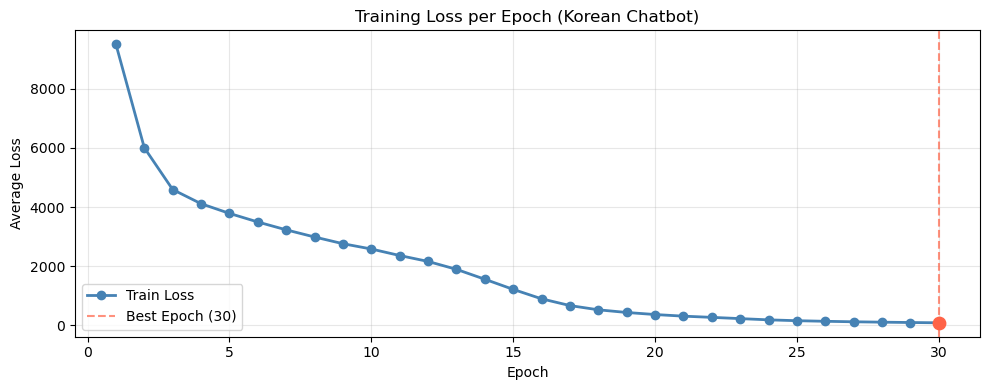

Best Loss : 82.4439  (Epoch 30)
Last Loss : 82.4439  (Epoch 30)


In [20]:
plt.figure(figsize=(10, 4))
epochs_x = list(range(1, len(loss_history) + 1))

plt.plot(epochs_x, loss_history, marker='o', linewidth=2,
         color='steelblue', label='Train Loss')

best_epoch = loss_history.index(min(loss_history)) + 1
plt.axvline(x=best_epoch, color='tomato', linestyle='--', alpha=0.7,
            label=f'Best Epoch ({best_epoch})')
plt.scatter([best_epoch], [min(loss_history)], color='tomato', zorder=5, s=80)

plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss per Epoch (Korean Chatbot)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_history.png", dpi=120)
plt.show()

print(f"Best Loss : {min(loss_history):.4f}  (Epoch {best_epoch})")
print(f"Last Loss : {loss_history[-1]:.4f}  (Epoch {len(loss_history)})")


## 20. 챗봇 추론 테스트 — Greedy Decoding

학습이 끝난 모델로 실제 챗봇 응답을 확인합니다.  
`<s>`(BOS) 토큰부터 시작해 `</s>`(EOS)가 생성될 때까지 토큰을 하나씩 예측합니다.

> Greedy Decoding은 매 스텝에서 확률이 가장 높은 토큰 하나만 선택합니다.  
> 빠르지만 전역 최적 응답을 보장하지 않습니다. 아래 셀의 Beam Search와 결과를 비교해 보세요.


In [21]:
def respond(question, model=transformer, max_len=40):
    """한국어 질문 → 챗봇 답변 생성 (Greedy Decoding)"""
    model.eval()
    question = preprocess_sentence(question)

    src_ids  = tokenizer.encode_as_ids(question)
    src_ids  = ([1] + src_ids + [2])[:max_len]
    src_ids += [0] * (max_len - len(src_ids))
    src = torch.tensor([src_ids], dtype=torch.long).to(device)

    tgt = torch.tensor([[1]], dtype=torch.long).to(device)

    with torch.no_grad():
        for _ in range(max_len):
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt)
            out, *_ = model(src, tgt, enc_mask, dec_enc_mask, dec_mask)
            next_tok = out[:, -1, :].argmax(dim=-1, keepdim=True)
            tgt = torch.cat([tgt, next_tok], dim=1)
            if next_tok.item() == 2:
                break

    ids = [i for i in tgt[0].tolist() if i not in (0, 1, 2)]
    return tokenizer.decode_ids(ids)


test_inputs = [
    "오늘 기분이 어때?",
    "요즘 너무 힘들어.",
    "좋은 영화 추천해줘.",
    "밥은 먹었어?",
    "내일 날씨가 어떨까?",
]

print("=" * 65)
print(f"{'질문':<30} │ Greedy 답변")
print("=" * 65)
for q in test_inputs:
    print(f"{q:<30} │ {respond(q)}")
print("=" * 65)


질문                             │ Greedy 답변
오늘 기분이 어때?                     │ 다른 친구를 충분히 알긴 바로 생각만 해도 군침이 항상 후회만 더 한 자연스럽게 생각해보세요.
요즘 너무 힘들어.                     │ 많이 없죠.
좋은 영화 추천해줘.                    │ 생각 있을 거예요.
밥은 먹었어?                        │ 다른 친구를 충분히 알긴 바로 생각만 해도 군침이 수록 좋아요 없죠.
내일 날씨가 어떨까?                    │ 사랑에되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지던게던게던게한 사람은 그러게 나를 충분히 말해달라고


## 21. 🆕 챗봇 추론 — Beam Search + Length Penalty

### Beam Search란?

Greedy Decoding이 매 스텝 1개의 토큰만 선택하는 반면,  
Beam Search는 **상위 `beam_size`개의 후보 시퀀스를 동시에 유지**하며 탐색합니다.

```
Greedy:   A → B → C → D       (매번 가장 높은 확률 하나만 선택)
Beam(3):  A → {B1, B2, B3}    (3개 후보 유지)
          → {C1, C2, C3}       (각 후보에서 확장, 상위 3개 유지)
          ...
```

### 🆕 Length Penalty (α = 0.6)

Beam Search는 짧은 문장을 선호하는 경향이 있습니다.  
Length Penalty로 길이에 비례한 보정을 적용해 자연스러운 길이의 답변을 유도합니다.

$$score = \frac{\log P(y|x)}{\left(\frac{5 + |y|}{6}\right)^\alpha}$$

| 파라미터 | 값 | 설명 |
|---------|-----|------|
| `beam_size` | 5 | 동시에 유지할 후보 수 |
| `alpha` | 0.6 | Length Penalty 강도 (0=없음, 1=강함) |
| `max_len` | 40 | 최대 생성 길이 |


In [22]:
def beam_search_respond(question, model=transformer,
                        beam_size=5, alpha=0.6, max_len=40):
    """
    한국어 질문 → 챗봇 답변 생성 (Beam Search + Length Penalty)
    - beam_size : 유지할 후보 시퀀스 수
    - alpha     : Length Penalty 강도 (0.0 = 패널티 없음)
    - max_len   : 최대 생성 토큰 수
    """
    model.eval()
    question = preprocess_sentence(question)

    src_ids  = tokenizer.encode_as_ids(question)
    src_ids  = ([1] + src_ids + [2])[:max_len]
    src_ids += [0] * (max_len - len(src_ids))
    src = torch.tensor([src_ids], dtype=torch.long).to(device)

    # 초기 빔: (토큰 시퀀스, 누적 log-prob)
    beams     = [([1], 0.0)]
    completed = []

    with torch.no_grad():
        for _ in range(max_len):
            candidates = []
            for seq, score in beams:
                if seq[-1] == 2:            # EOS면 완료 처리
                    completed.append((seq, score))
                    continue

                tgt = torch.tensor([seq], dtype=torch.long).to(device)
                enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt)
                out, *_ = model(src, tgt, enc_mask, dec_enc_mask, dec_mask)

                log_probs = F.log_softmax(out[:, -1, :], dim=-1)
                top_log_probs, top_ids = log_probs.topk(beam_size)

                for log_p, idx in zip(top_log_probs[0], top_ids[0]):
                    new_seq   = seq + [idx.item()]
                    new_score = score + log_p.item()
                    candidates.append((new_seq, new_score))

            if not candidates:
                break

            # Length Penalty 적용 후 상위 beam_size 유지
            def length_penalty(seq, score):
                length = len([t for t in seq if t not in (0, 1, 2)])
                lp = ((5 + max(length, 1)) / 6) ** alpha
                return score / lp

            beams = sorted(candidates, key=lambda x: length_penalty(x[0], x[1]),
                           reverse=True)[:beam_size]

            # 모든 빔이 EOS에 도달하면 종료
            if all(s[-1] == 2 for s, _ in beams):
                completed.extend(beams)
                break

    if not completed:
        completed = beams

    # 최고 점수 시퀀스 선택
    best_seq = max(completed, key=lambda x: length_penalty(x[0], x[1]))[0]
    ids = [i for i in best_seq if i not in (0, 1, 2)]
    return tokenizer.decode_ids(ids)


# ── Greedy vs Beam Search 비교 ────────────────────────────────────────────────
print("=" * 75)
print(f"{'질문':<25} │ {'Greedy':<22} │ Beam Search (size=5)")
print("=" * 75)
for q in test_inputs:
    g = respond(q)
    b = beam_search_respond(q)
    print(f"{q:<25} │ {g:<22} │ {b}")
print("=" * 75)


질문                        │ Greedy                 │ Beam Search (size=5)
오늘 기분이 어때?                │ 다른 친구를 충분히 알긴 바로 생각만 해도 군침이 항상 후회만 더 한 자연스럽게 생각해보세요. │ 다른 친구를 충분히 알긴 바로 생각만 해도 군침이 항상 후회만 더 한 자연스럽게 생각해보세요.
요즘 너무 힘들어.                │ 많이 없죠.                 │ 많이 없죠.
좋은 영화 추천해줘.               │ 생각 있을 거예요.             │ 생각 있을 거예요.
밥은 먹었어?                   │ 다른 친구를 충분히 알긴 바로 생각만 해도 군침이 수록 좋아요 없죠. │ 다른 친구를 충분히 알긴 바로 생각만 해도 군침이 수록 좋아요 없죠.
내일 날씨가 어떨까?               │ 사랑에되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지던게던게던게한 사람은 그러게 나를 충분히 말해달라고 │ 사랑에되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지되겠지던게던게던게한 사람은 그러게지 않을 거예요.


## 22. BLEU Score 평가

테스트셋에 대한 응답 품질을 BLEU Score로 정량 평가합니다.  
Greedy와 Beam Search 결과를 동시에 비교해 어떤 디코딩 전략이 더 나은지 확인합니다.

> BLEU Score는 참고 답변과의 n-gram 겹침을 기반으로 측정됩니다.  
> 챗봇 특성상 다양한 정답이 존재하므로, BLEU는 보조 지표로만 활용하세요.


In [23]:
import nltk
nltk.download('punkt', quiet=True)

smooth = SmoothingFunction().method1

greedy_scores = []
beam_scores   = []

eval_samples = min(50, len(test_questions))

for q, ref_a in zip(test_questions[:eval_samples], test_answers[:eval_samples]):
    ref_tokens = list(ref_a)

    hyp_greedy = list(respond(q))
    hyp_beam   = list(beam_search_respond(q))

    if len(hyp_greedy) > 0:
        greedy_scores.append(
            sentence_bleu([ref_tokens], hyp_greedy, smoothing_function=smooth))
    if len(hyp_beam) > 0:
        beam_scores.append(
            sentence_bleu([ref_tokens], hyp_beam, smoothing_function=smooth))

avg_greedy = sum(greedy_scores) / len(greedy_scores) if greedy_scores else 0.0
avg_beam   = sum(beam_scores)   / len(beam_scores)   if beam_scores   else 0.0

print(f"{'평가 샘플 수':<20}: {eval_samples}")
print(f"{'Greedy BLEU':<20}: {avg_greedy:.4f}")
print(f"{'Beam Search BLEU':<20}: {avg_beam:.4f}")
print()
print("─" * 65)
print("샘플 비교 (Q / 정답 / Greedy / Beam Search):")
print("─" * 65)
for q, ref_a in zip(test_questions[:5], test_answers[:5]):
    print(f"  Q       : {q}")
    print(f"  정답    : {ref_a}")
    print(f"  Greedy  : {respond(q)}")
    print(f"  Beam    : {beam_search_respond(q)}")
    print()


평가 샘플 수             : 50
Greedy BLEU         : 0.0297
Beam Search BLEU    : 0.0315

─────────────────────────────────────────────────────────────────
샘플 비교 (Q / 정답 / Greedy / Beam Search):
─────────────────────────────────────────────────────────────────
  Q       : 짝남한테 은근슬쩍 나쁘지 않아하는 티 내는 방법 좀.
  정답    : 은근히 칭찬해주는 건 어떨까요.
  Greedy  : 다른 친구를 조금만 없죠.
  Beam    : 다른 친구를 조금만 더 좋겠 꿈이니 다행이에요.

  Q       : 나 좀 괜찮아해줬으면
  정답    : 먼저 다가가 보세요.
  Greedy  : 생각을 자신을 좋은 누구나 더 좋은 누구나 떠나세요.
  Beam    : 생각을 자신을 좋은 누구나 더 좋은 누구나 떠나세요.

  Q       : 학원에 나쁘지 않아하는 남자애가 생겼어요.
  정답    : 물어볼 거 있다고 하면서 개인적으로 말해보세요.
  Greedy  : 다른 친구를 충분히 알긴 바로 생각만 해도 군침이 수록 좋아요.
  Beam    : 다른 친구를 충분히 알긴 바로 생각만 해도 군침이 수록 좋아요.

  Q       : 언젠가는 나를 나쁘지 않아해 주는 사람 있겠지?
  정답    : 저도 괜찮아해요.
  Greedy  : 사람마다 행복은 그러게 사람이에요.
  Beam    : 사람마다 행복은 그러게 사람이에요.

  Q       : 괜찮아하는 남자애가 바람둥이 같은데 계속 좋아하면 안되겠죠?
  정답    : 상처받지 않았으면 좋겠네요.
  Greedy  : 다정한랑 이야기컴컴컴컴컴 5 부담스럽지 선물은 삶을 가져보세요.
  Beam    : 다정한랑 이야기컴컴컴컴 5 부담스럽지 선물은 삶을 가져보세요.

